In [8]:
 #Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

#Load Dataset
df = pd.read_excel("School data.xlsx")
#first 5 rows
df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [7]:
import pandas as pd
df = pd.read_excel("School data.xlsx")

In [9]:
# Data Understanding
print(df.shape)
df.info()
df.describe()

(5200, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          4940 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             4940 non-null   float64
 12  Functional_Toilets             5200 n

,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
count,4942.000000,5200.000000,5200.000000,4940.000000,5200.000000,5200.000000,5200.000000,4940.000000,5200.000000,5200.000000,5200.000000,5200.000000,4941.000000
mean,60.055898,62.970896,61.338762,29.980951,8.096596,1.995385,0.895577,0.295344,0.954423,0.483462,30.401288,16.770077,49.776644
std,15.106160,16.569802,18.025438,9.957824,3.916906,1.430434,0.305838,0.456243,0.208586,0.499774,11.916650,12.773571,16.936643
min,0.326857,1.380000,1.510000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000
25%,49.582500,51.520000,48.890000,23.100000,5.400000,1.000000,1.000000,0.000000,1.000000,0.000000,22.300000,6.200000,38.400000
50%,59.850000,63.030000,61.150000,29.800000,8.000000,2.000000,1.000000,0.000000,1.000000,0.000000,31.000000,15.200000,49.500000
75%,70.630000,74.452500,73.950000,36.600000,10.800000,3.000000,1.000000,1.000000,1.000000,1.000000,38.800000,25.300000,60.800000
max,107.344878,100.000000,100.000000,100.000000,22.700000,9.000000,1.000000,1.000000,1.000000,1.000000,73.100000,66.000000,150.000000


In [5]:
# Data Cleaning
#Check missing values
df.isnull().sum()

School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64

In [21]:
#Fill missing values (numerical columns with mean)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [24]:
#Check duplicates
df.duplicated().sum()
# Remove duplicates
df.drop_duplicates(inplace=True)    #Duplicate rows removed

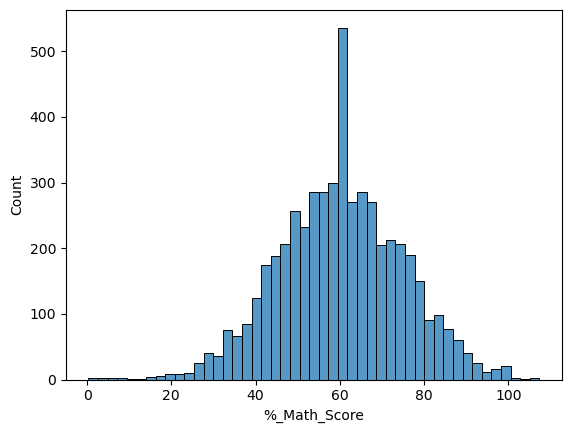

In [20]:
sns.histplot(df['%_Math_Score'])
plt.show()

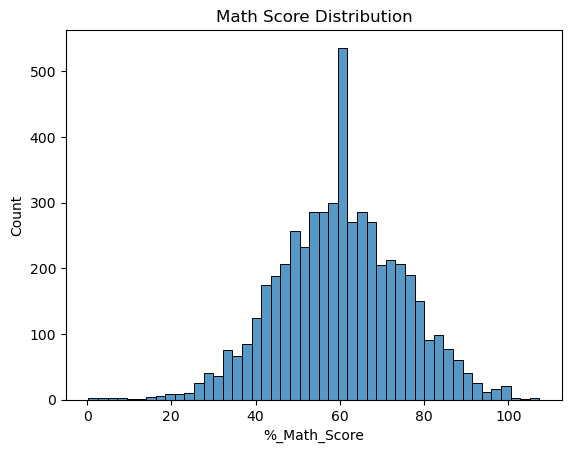

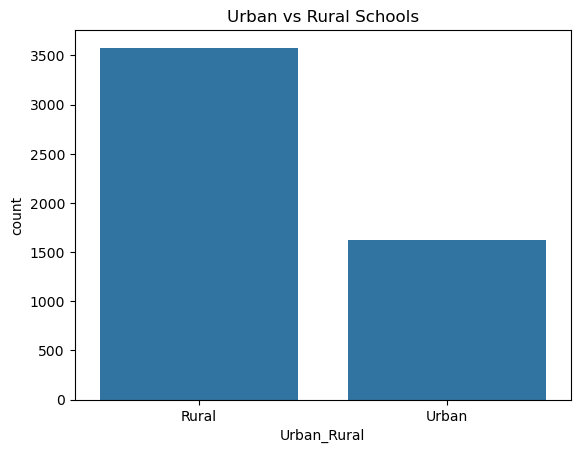

In [22]:
#STEP 5: Exploratory Data Analysis (EDA)
# -------- Univariate Analysis --------

# Distribution of Math Score
sns.histplot(df['%_Math_Score'])
plt.title("Math Score Distribution")
plt.show()

# Count of Urban vs Rural schools
sns.countplot(x='Urban_Rural', data=df)
plt.title("Urban vs Rural Schools")
plt.show()


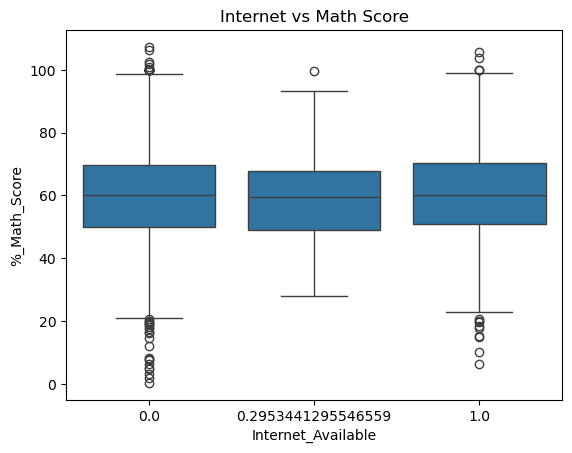

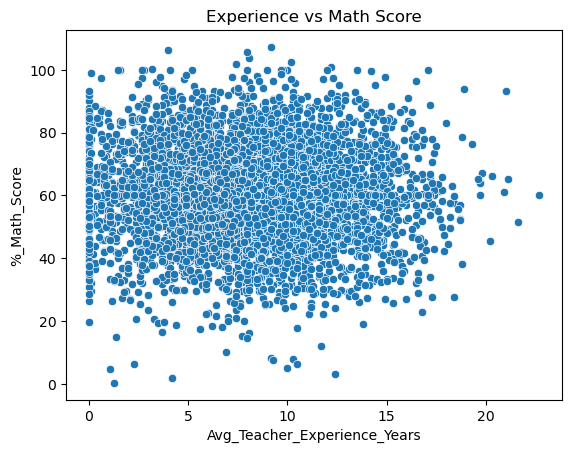

In [23]:
# Bivariate Analysis

# Internet availability vs Math Score
sns.boxplot(x='Internet_Available', y='%_Math_Score', data=df)
plt.title("Internet vs Math Score")
plt.show()

# Teacher Experience vs Math Score
sns.scatterplot(x='Avg_Teacher_Experience_Years', y='%_Math_Score', data=df)
plt.title("Experience vs Math Score")
plt.show()

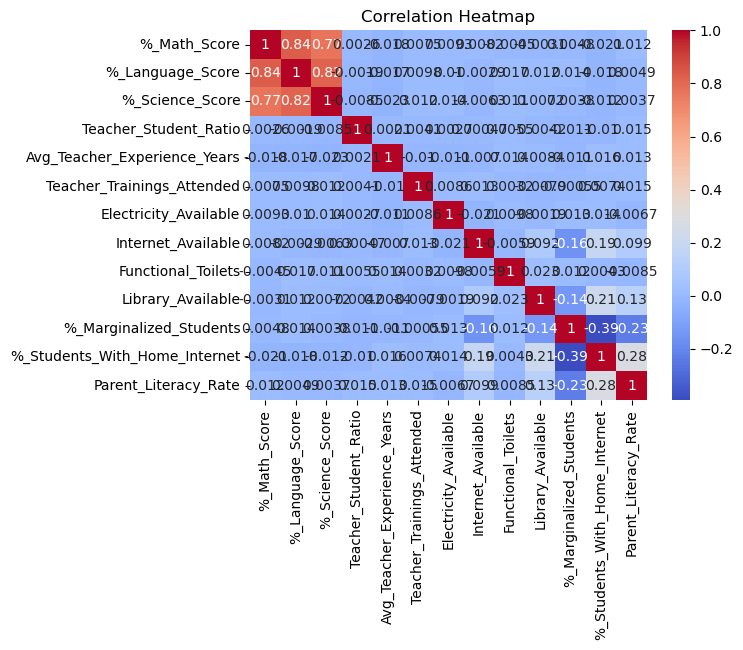

In [24]:
# Correlation Analysis 

# Correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# STEP 6: Feature Engineering (Optional)

# Create average score column
df['Average_Score'] = (df['%_Math_Score'] + df['%_Language_Score'] + df['%_Science_Score']) / 3

df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate,Average_Score
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.100000,5.7,1,1,0.0,1,0,29.7,5.7,33.9,47.026667
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,29.980951,5.8,1,1,0.0,0,0,36.1,4.0,40.6,82.806667
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.900000,7.1,2,1,1.0,0,0,38.9,17.4,47.6,43.750000
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.600000,2.6,1,1,1.0,0,0,11.2,35.8,73.3,42.610000
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.800000,6.1,1,1,0.0,1,0,33.1,13.6,35.3,48.780000


In [26]:
# STEP 7: Insights (Write in Markdown)

# 1. Internet availability improves student performance
# 2. Teacher experience positively impacts scores
# 3. Rural schools show slightly lower performance
# 4. Higher teacher-student ratio reduces performance
# 5. Better facilities lead to better results

In [10]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [11]:
# STEP 2: LOAD DATA

df = pd.read_excel("School data.xlsx")

print("Data Loaded")
df.head()

Data Loaded


,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [16]:
# STEP 3: CLEAN DATA

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Data Cleaned")

Data Cleaned


In [17]:
# STEP 4: CREATE TARGET

df['Average_Score'] = (df['%_Math_Score'] + 
                      df['%_Language_Score'] + 
                      df['%_Science_Score']) / 3

print("Target Created")

Target Created


In [18]:
# STEP 5: DEFINE X & y

X = df[['Teacher_Student_Ratio',
        'Avg_Teacher_Experience_Years',
        'Teacher_Trainings_Attended',
        'Electricity_Available',
        'Internet_Available',
        'Functional_Toilets',
        'Library_Available',
        '%_Marginalized_Students',
        '%_Students_With_Home_Internet',
        'Parent_Literacy_Rate']]

y = df['Average_Score']

print("X and y Ready")

X and y Ready


In [20]:
# STEP 6: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split Done")

Split Done


In [21]:
# STEP 7: TRAIN MODEL

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained")

Model Trained


In [22]:
# STEP 8: PREDICTION

y_pred = model.predict(X_test)

print("Prediction Done")

Prediction Done


In [23]:
# STEP 9: EVALUATION
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 12.639821606608852
R2 Score: -0.0034353348005022877
